<style>
@media print {
    @page {
        margin: 1.55rem; /* Reduces default margins significantly */
    }
}
</style>

# Lab Expirement: Advanced Deep Learning for Sentiment Engineering
**Course:** COSC 442 - Artificial Intelligence 
**Duration:** 60 Minutes | **Dataset:** FER-2013

--- 

## 1. Objective
In this lab, you will engineer a multi-stage Convolutional Neural Network (CNN) to interpret human emotional signals.

## 2. Architecture: CNNs as Spatial Filter Banks
* **Convolutional Layers:** These are the 'sensors' of the network. Each $3 \times 3$ or $5 \times 5$ kernel learns to respond to specific frequencies—edges, curves, or textures.
* **Batch Normalization:** This acts as a signal regulator, ensuring that the 'voltage' (gradients) remains stable as it propagates through deep layers.
* **Pooling:** Reduces spatial resolution to extract the dominant feature, providing robustness to head tilt and position.

## 3. Data Engineering & Streaming
We utilize the directory-based structure of FER-2013. Instead of loading thousands of images into memory, we create a streaming pipeline.

In [1]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013", output_dir="./dataset")

print("Path to dataset files:", path)

# Update your directory paths to point to the downloaded location
TRAIN_DIR = os.path.join(path, 'train')
TEST_DIR = os.path.join(path, 'test')

100%|██████████| 60.3M/60.3M [00:04<00:00, 14.1MB/s]

Extracting files...


Path to dataset files: ./dataset


In [2]:
# Check available devices

from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())


I0000 00:00:1776781504.667483 1415554 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 8963766978045237927
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 9180348416
locality {
  bus_id: 1
  links {
  }
}
incarnation: 10273848981385767787
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:29:00.0, compute capability: 8.6"
xla_global_id: 416903419
]


I0000 00:00:1776781507.135830 1415554 gpu_device.cc:2043] Created device /device:GPU:0 with 8755 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:29:00.0, compute capability: 8.6


In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Signal Augmentation Pipeline
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=True
)

validation_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


## 4. Architectural Implementation
We implement a modular, high-depth architecture.

In [4]:
from tensorflow.keras import layers, models, optimizers

def build_advanced_model():
    model = models.Sequential()

    model.add(layers.Input(shape=(48, 48, 1))) # The new way
    # Block 1: Edges
    model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 2: Complex Shapes
    model.add(layers.Conv2D(128, (5, 5), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    # Fully Connected Logic
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(7, activation='softmax'))

    model.compile(optimizer=optimizers.Adam(learning_rate=0.001), 
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_advanced_model()
model.summary()

I0000 00:00:1776781507.635877 1415554 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8755 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:29:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,946,311 (18.87 MB)

 Trainable params: 4,945,351 (18.87 MB)

 Non-trainable params: 960 (3.75 KB)

## 5. Optimization Loop & Transient Analysis
We use adaptive callbacks to ensure smooth convergence.

In [5]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1)
early_stopper = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=[lr_reducer, early_stopper]
)

Epoch 1/15


I0000 00:00:1776781508.517975 1415554 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1776781510.171861 1416231 service.cc:153] XLA service 0x7f70940072d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776781510.171878 1416231 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.3.0; Toolkit: 12.5.0; DNN: 9.21.0)
I0000 00:00:1776781510.218260 1416231 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776781510.511984 1416231 cuda_dnn.cc:461] Loaded cuDNN version 92100
I0000 00:00:1776781510.611871 1416231 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3990__.60
I0000 00:00:1776781512.416078 1416357 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 712

  1/449 ━━━━━━━━━━━━━━━━━━━━ 1:27:02 12s/step - accuracy: 0.1562 - loss: 2.8104

I0000 00:00:1776781519.976479 1416231 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


422/449 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2314 - loss: 2.3350

I0000 00:00:1776781528.902643 1416232 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3990__.60


449/449 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.2745 - loss: 2.0541 - val_accuracy: 0.2785 - val_loss: 1.8901 - learning_rate: 0.0010
Epoch 2/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.3864 - loss: 1.6036 - val_accuracy: 0.4670 - val_loss: 1.4023 - learning_rate: 0.0010
Epoch 3/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.4409 - loss: 1.4511 - val_accuracy: 0.4982 - val_loss: 1.3279 - learning_rate: 0.0010
Epoch 4/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.4825 - loss: 1.3640 - val_accuracy: 0.5209 - val_loss: 1.2727 - learning_rate: 0.0010
Epoch 5/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.4952 - loss: 1.3251 - val_accuracy: 0.5386 - val_loss: 1.2111 - learning_rate: 0.0010
Epoch 6/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.5114 - loss: 1.2831 - val_accuracy: 0.5407 - val_loss: 1.2955 - learning_rate: 0.0010
Epoch 7/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.5218 - loss: 1.2655

## 6. Diagnostic Evaluation: Confusion Matrix
Analyze 'Emotional Cross-talk'—where does the model fail?

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


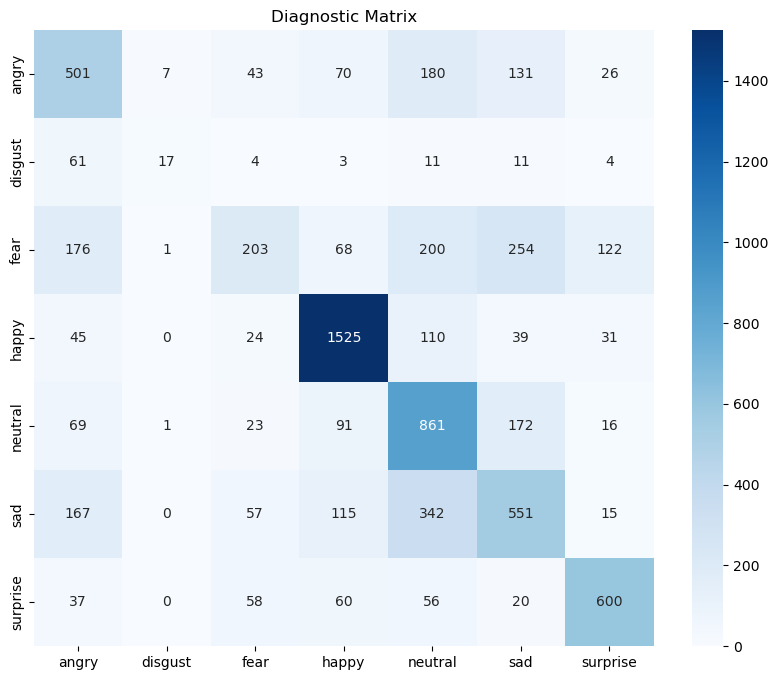

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.title('Diagnostic Matrix')
plt.show()

## 7. Real-Time Deployment
Apply the trained weights to a live video stream.

In [7]:
import cv2

cap = cv2.VideoCapture(0)
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

while True:
    ret, frame = cap.read()
    if not ret: break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        roi = cv2.resize(gray[y:y+h, x:x+w], (48, 48))
        roi = roi.astype('float32') / 255.0
        roi = np.expand_dims(np.expand_dims(roi, -1), 0)
        
        prediction = model.predict(roi, verbose=0)
        label = class_labels[np.argmax(prediction)]
        
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
        cv2.putText(frame, label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

    cv2.imshow('Live Sentiment Analyzer', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'): break

cap.release()
cv2.destroyAllWindows()

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/eslamallam/Projects/python/sentiment-analysis/.pixi/envs/default/lib/python3.12/site-packages/cv2/qt/plugins"
QObject::moveToThread: Current thread (0x55d14f1a9440) is not the object's thread (0x55d14fca0000).
Cannot move to target thread (0x55d14f1a9440)

QObject::moveToThread: Current thread (0x55d14f1a9440) is not the object's thread (0x55d14fca0000).
Cannot move to target thread (0x55d14f1a9440)

QObject::moveToThread: Current thread (0x55d14f1a9440) is not the object's thread (0x55d14fca0000).
Cannot move to target thread (0x55d14f1a9440)

QObject::moveToThread: Current thread (0x55d14f1a9440) is not the object's thread (0x55d14fca0000).
Cannot move to target thread (0x55d14f1a9440)

QObject::moveToThread: Current thread (0x55d14f1a9440) is not the object's thread (0x55d14fca0000).
Cannot move to target thread (0x55d14f1a9440)

QObject::moveToThread: Current thread (0x55d14f1a9440) is not the object's thread 

---
## Take-Home Assignment: Adversarial Feature Sabotage
**Task 1: Occlusion Sensitivity** 
Make a 'Happy' face. Now cover your mouth. Does the prediction shift? Analyze why the eyes alone might not be a 'strong enough signal' for this specific architecture.

**Task 2: Architecture Tuning** 
Remove the `BatchNormalization` layers. Record the convergence speed. Explain how normalization acts as a 'stabilizer' in deep signals.

**Task 3: Threshold Tuning** 
Adjust the live code to only show a label if confidence $> 0.8$. Which emotions are the most 'uncertain'?